### Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn
from tensorflow import keras
from sklearn.model_selection import train_test_split

%matplotlib inline

In [5]:
# # In case of errors, check if you are using the correct versions of the libraries. This notebook works on the following versions of libraries. Specify these versions if you get version related errors.
# TensorFlow version: 2.17.0
# Pandas version: 2.2.2
# NumPy version: 1.26.4
# Scikit-learn version: 1.5.2
# Keras version: 3.4.1

# print("TensorFlow version:", tf.__version__)
# print("Pandas version:", pd.__version__)
# print("NumPy version:", np.__version__)
# print("Scikit-learn version:", sklearn.__version__)
# print("Keras version:", tf.keras.__version__)

### Loading data

In [2]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

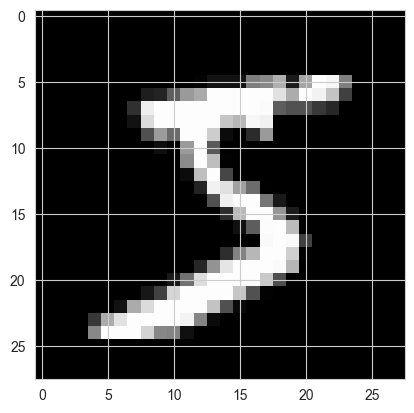

In [3]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap="gray")
plt.show()

In [4]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10),
    ]
)
dir(model)

/Users/deven/.virtualenvs/ML_AI/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


['__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_trackable_child',
 '_add_variable_with_custom_getter',
 '_aggregate_additional_loss',
 '_allow_non_tensor_positional_args',
 '_api_export_path',
 '_api_export_symbol_id',
 '_assert_compile_called',
 '_assert_input_compatibility',
 '_assign_variable_values',
 '_auto_config',
 '_autoconvert_optionals',
 '_build_at_init',
 '_build_by_run_for_kwargs',
 '_build_by_run_for_single_pos_arg',
 '_build_shapes_dict',
 '_call_context_args',
 '_call_has_context_arg',
 '_call_has_mask_arg',
 '_call_has_training_arg',
 '_call_signature',
 '_called',
 '_check_load_own_variables',
 '_check_quantize_args

In [5]:
predictions = model(x_train[:1]).numpy()
predictions

array([[ 0.4523307 , -0.13681452,  0.09378588, -0.02354631,  0.02925508,
        -0.18947877, -0.74408305, -0.40500146, -0.12793633, -0.6372554 ]],
      dtype=float32)

In [6]:
tf.nn.softmax(predictions).numpy()

array([[0.17609121, 0.09769564, 0.12303358, 0.10941248, 0.11534486,
        0.0926837 , 0.0532282 , 0.07471418, 0.09856685, 0.05922928]],
      dtype=float32)

In [7]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [8]:
loss_fn(y_train[:1], predictions).numpy()

np.float32(2.3785625)

In [9]:
model.compile(optimizer="adam", loss=loss_fn, metrics=["accuracy"])

In [10]:
model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test, verbose=2)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 501us/step - accuracy: 0.9139 - loss: 0.2955
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 507us/step - accuracy: 0.9577 - loss: 0.1429
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 509us/step - accuracy: 0.9679 - loss: 0.1081
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 510us/step - accuracy: 0.9723 - loss: 0.0880
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 505us/step - accuracy: 0.9765 - loss: 0.0742
313/313 - 0s - 372us/step - accuracy: 0.9789 - loss: 0.0720


[0.07202710211277008, 0.9789000153541565]

In [11]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])

In [12]:
probability_model(x_test[:5])

<tf.Tensor: shape=(5, 10), dtype=float32, numpy=
array([[1.32922537e-07, 1.35550327e-08, 5.81123004e-07, 1.25760953e-05,
        9.12459865e-12, 2.63651884e-07, 2.19229186e-14, 9.99985337e-01,
        3.15992395e-07, 9.10265840e-07],
       [2.14645262e-08, 3.71742615e-04, 9.99595702e-01, 1.36716690e-05,
        1.01362315e-14, 7.23767002e-08, 8.81359519e-09, 7.56113401e-12,
        1.88489194e-05, 4.78232634e-13],
       [7.81963081e-08, 9.99592602e-01, 5.07489494e-05, 1.07372523e-06,
        3.46755660e-05, 1.50473252e-05, 1.65093988e-05, 2.21070761e-04,
        6.61695449e-05, 2.01625539e-06],
       [9.99989510e-01, 2.55039101e-10, 6.16740772e-06, 4.16164037e-09,
        1.86333708e-07, 8.88360262e-07, 2.63694619e-06, 5.77181254e-07,
        2.52222883e-08, 7.68538300e-09],
       [7.60574676e-06, 4.35005754e-10, 5.36064581e-05, 1.04390381e-07,
        9.85182345e-01, 1.60944564e-05, 3.94289418e-06, 1.65321355e-04,
        3.51919812e-06, 1.45673426e-02]], dtype=float32)>

### Extracting feature variables and target variable

In [9]:
data_y = data["label"].values
data_x = data.drop("label", axis=1)

In [10]:
data_x.head(2)

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Data visualization

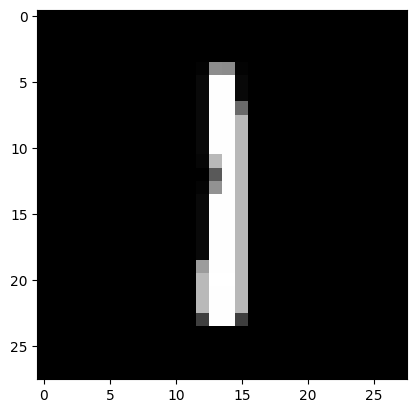

In [11]:
img = data_x.iloc[2].values.reshape((28, 28))
plt.imshow(img, cmap="gray")

In [12]:
set(data_y)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    data_x, data_y, test_size=0.1, random_state=42
)

### Model Building

In [17]:
# model = keras.Sequential([
#     keras.layers.Dense(128, activation=tf.nn.relu, input_shape=(784,)),
#     keras.layers.Dense(128, activation=tf.nn.relu),
#     keras.layers.Dense(128, activation=tf.nn.relu),
#     keras.layers.Dense(10, activation=tf.nn.softmax)])

# Newer versions of Keras support this:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(784,)),
        keras.layers.Dense(128, activation=tf.nn.relu),
        keras.layers.Dense(128, activation=tf.nn.relu),
        keras.layers.Dense(128, activation=tf.nn.relu),
        keras.layers.Dense(10, activation=tf.nn.softmax),
    ]
)

In [18]:
model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

### Model training

In [19]:
model.fit(X_train, y_train, batch_size=64, epochs=5, validation_data=(X_val, y_val))

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7629 - loss: 5.5944 - val_accuracy: 0.8933 - val_loss: 0.6175
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9247 - loss: 0.3884 - val_accuracy: 0.9236 - val_loss: 0.3980
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9461 - loss: 0.2137 - val_accuracy: 0.9343 - val_loss: 0.3009
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9571 - loss: 0.1555 - val_accuracy: 0.9429 - val_loss: 0.2739
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9628 - loss: 0.1404 - val_accuracy: 0.9405 - val_loss: 0.3027


### Model evaluation

In [20]:
model.predict(X_test).argmax(axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([2, 0, 9, ..., 3, 9, 2])

875/875 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
The predicted label is: 0


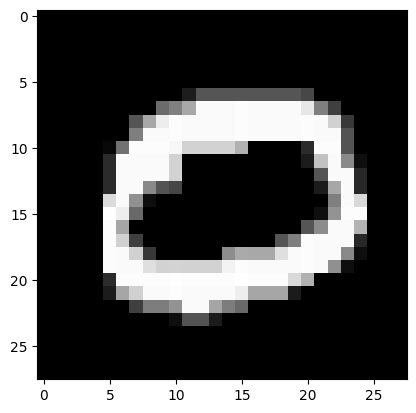

In [21]:
img = X_test.iloc[1].values.reshape((28, 28))
plt.imshow(img, cmap="gray")
print("The predicted label is:", model.predict(X_test).argmax(axis=1)[1])

Further ahead: You can try increasing the model layers and play with the hyperparameters to increase model's performance